In [14]:
%cd /Users/masha/Documents/visual-reasoning

import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torchvision import transforms

import matplotlib.pyplot as plt
import timm
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")

BATCH_SIZE = 16
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# --- Reproducible balanced test set sampling from raw Ganis-Kievit stimuli ---
import os
import glob
import random
from pathlib import Path
import cv2

SEED = 42
N_TEST_PER_CLASS = 39  # total test size = 2 * N_TEST_PER_CLASS
GANIS_STIM_PATH = "./data/ganis_kievit_data/stimuli_jpgs"
OUTPUT_SIZE = (64, 64)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


def _process_pair_image(f_path: str):
    filename = Path(f_path).stem
    parts = filename.split('_')
    angle = int(parts[1])
    label = 'diff' if filename.endswith('_R') else 'same'

    img = cv2.imread(f_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f_path)

    h, w = img.shape
    left = img[:, :w // 2]
    right = img[:, w // 2:]

    x0 = cv2.resize(left, OUTPUT_SIZE)
    x1 = cv2.resize(right, OUTPUT_SIZE)

    # scale to [-1, 1] and add channel dim -> (1, 64, 64)
    x0 = (x0.astype(np.float32) / 127.5) - 1.0
    x1 = (x1.astype(np.float32) / 127.5) - 1.0

    return {
        'x0': np.expand_dims(x0, axis=0),
        'x1': np.expand_dims(x1, axis=0),
        'angle': angle,
        'name': filename,
        'label': label,
    }


def make_balanced_test_set(seed: int = SEED, n_per_class: int = N_TEST_PER_CLASS):
    files = sorted(glob.glob(os.path.join(GANIS_STIM_PATH, "*.jpg")))
    same_files = [f for f in files if not f.endswith('_R.jpg')]
    diff_files = [f for f in files if f.endswith('_R.jpg')]

    if n_per_class > len(same_files) or n_per_class > len(diff_files):
        raise ValueError(f"Requested n_per_class={n_per_class}, but have same={len(same_files)}, diff={len(diff_files)}")

    rng = np.random.default_rng(seed)
    same_sel = rng.choice(same_files, size=n_per_class, replace=False)
    diff_sel = rng.choice(diff_files, size=n_per_class, replace=False)

    test_files = list(same_sel) + list(diff_sel)
    rng.shuffle(test_files)

    return [_process_pair_image(f) for f in test_files]


test_raw = make_balanced_test_set(SEED, N_TEST_PER_CLASS)
print(f"Sampled test_raw: {len(test_raw)} ({N_TEST_PER_CLASS} same + {N_TEST_PER_CLASS} diff), seed={SEED}")


/Users/masha/Documents/visual-reasoning
Sampled test_raw: 78 (39 same + 39 diff), seed=42


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dinov3 = timm.create_model(
    "vit_small_patch16_dinov3",
    pretrained=True
)

dinov3.to(device)
dinov3.eval()

# Ensure nothing is trainable
for p in dinov3.parameters():
    p.requires_grad = False

@torch.no_grad()
def embed(x):
    x = x.to(device)
    # feats = dinov3.forward_features(x)
    feats = dinov3(x)
    
    # CLS token or mean-pooling — pick ONE and stick to it
    if feats.dim() == 3:
        feats = feats.mean(dim=1)        # global pooled
    
    return feats

In [16]:
all_sims = []
all_labels = []

train_raw = np.load('./data/train_pairs.npy', allow_pickle=True)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def prepare_data(raw_list, is_train=False):
    # Stack all images into one tensor (N, 1, 64, 64)
    x0 = torch.tensor(np.stack([d['x0'] for d in raw_list])).float()
    x1 = torch.tensor(np.stack([d['x1'] for d in raw_list])).float()
    
    # DINOv3 requires 3-channel input even for grayscale data
    x0 = x0.repeat(1, 3, 1, 1)
    x1 = x1.repeat(1, 3, 1, 1)
    
    # Normalize with respect to ImageNet for DINOv3
    x0 = (x0 + 1) * 0.5 
    x1 = (x1 + 1) * 0.5
    # print(x0, x1)
    
    # Apply ImageNet Normalization
    normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    x0 = normalize(x0)
    x1 = normalize(x1)
    
    if is_train:
        y = torch.ones(len(raw_list))
    else:
        y = torch.tensor([1.0 if d.get('label') == 'same' else 0.0 for d in raw_list])
        
    return x0, x1, y

train_x0, train_x1, train_y = prepare_data(train_raw, is_train=True)
test_x0, test_x1, test_y = prepare_data(test_raw, is_train=False)

train_loader = DataLoader(TensorDataset(train_x0, train_x1, train_y), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(test_x0, test_x1, test_y), batch_size=32)

batch = next(iter(train_loader))
print(f"Batch Shape: {batch[0].shape}")
print(f"Label Shape: {batch[2].shape}")

with torch.no_grad():
    for x0, x1, y in test_loader:
        z0 = embed(x0)
        z1 = embed(x1)

        sims = F.cosine_similarity(z0, z1, dim=1)

        all_sims.append(sims.cpu())
        all_labels.append(y)

all_sims = torch.cat(all_sims).numpy()
all_labels = torch.cat(all_labels).numpy()

auc = roc_auc_score(all_labels, all_sims)
print("DINOv3 zero-shot ROC-AUC:", auc)


Batch Shape: torch.Size([32, 3, 64, 64])
Label Shape: torch.Size([32])
DINOv3 zero-shot ROC-AUC: 0.5693622616699541



--- DINOv3 Baseline Results ---
Mean Similarity (Same):      0.9364
Mean Similarity (Diff):      0.9276
Mean Distance (Same):      2.2433
Mean Distance (Diff):      2.4053
Baseline AUC Score from cosine similarity:          0.5634
Baseline AUC Score from Euclidean distance:        0.5608
Best-threshold Accuracy (cosine similarity):        0.5769  @ thr=0.9646
Best-threshold Accuracy (euclidean distance):      0.5769  @ dist_thr=1.9137


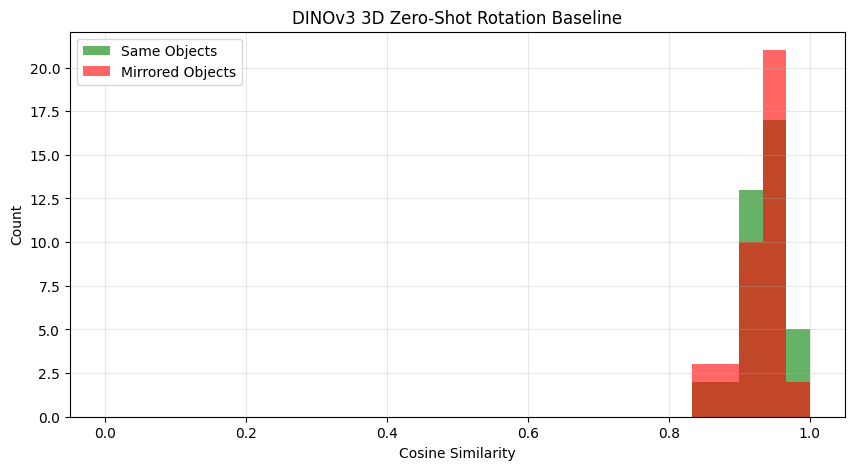

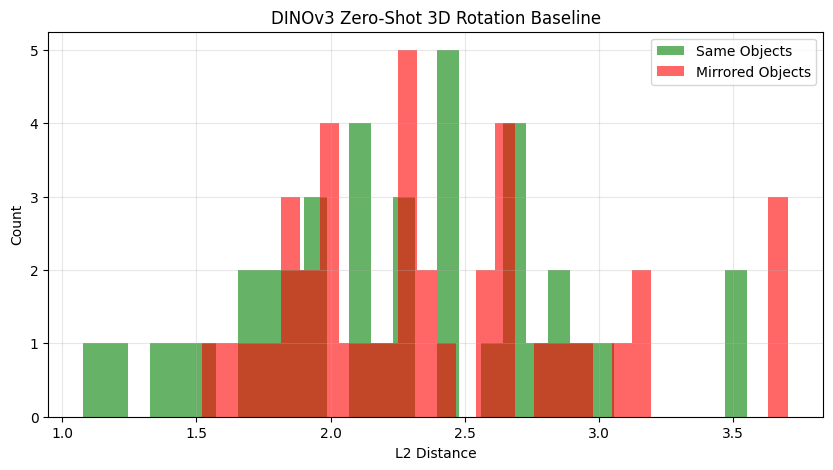

In [17]:

def prepare_baseline_data(raw_list):
    x0_np = np.stack([d['x0'] for d in raw_list])
    x1_np = np.stack([d['x1'] for d in raw_list])
    
    x0_t = torch.tensor(x0_np).float()
    x1_t = torch.tensor(x1_np).float()
    
    x0_t = F.interpolate(x0_t, size=(224, 224), mode='bilinear', align_corners=False)
    x1_t = F.interpolate(x1_t, size=(224, 224), mode='bilinear', align_corners=False)
    
    x0_t = x0_t.repeat(1, 3, 1, 1)
    x1_t = x1_t.repeat(1, 3, 1, 1)
    
    x0_t = (x0_t + 1) * 0.5 
    x1_t = (x1_t + 1) * 0.5
    
    normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    x0_t = normalize(x0_t)
    x1_t = normalize(x1_t)
    
    y = torch.tensor([1.0 if d.get('label') == 'same' else 0.0 for d in raw_list])
    
    return x0_t, x1_t, y

x0, x1, y = prepare_baseline_data(test_raw)
test_loader = DataLoader(TensorDataset(x0, x1, y), batch_size=BATCH_SIZE)

dinov3 = timm.create_model("vit_small_patch16_dinov3", pretrained=True, num_classes=0)
dinov3.to(device)
dinov3.eval()

sim_scores_same = []
sim_scores_diff = []
cos_labels = []
all_scores = []

dist_same = []
dist_diff = []
dist_labels = []
all_dists = []

with torch.no_grad():
    for bx0, bx1, by in test_loader:
        bx0, bx1 = bx0.to(device), bx1.to(device)
        
        # Extract features (CLS Token)
        # forward_features returns (B, N, D). Index 0 is CLS.
        # feats0 = dinov3.forward_features(bx0)[:, 0, :]
        feats0 = dinov3(bx0)
        # feats1 = dinov3.forward_features(bx1)[:, 0, :]
        feats1 = dinov3(bx1)
        
        # Compute cosine similarity
        similarity = F.cosine_similarity(feats0, feats1, dim=1).cpu().numpy()
        # Compute l2 norm directly on embeddings from dinov3
        feat_distance = torch.norm(feats0 - feats1, p=2, dim=1).cpu().numpy()
        
        labels = by.numpy()
        
        for i in range(len(labels)):
            score = similarity[i]
            lbl = labels[i]
            
            all_scores.append(score)
            cos_labels.append(lbl)
            
            if lbl == 1.0:
                sim_scores_same.append(score)
            else:
                sim_scores_diff.append(score)

        for i in range(len(labels)):
            d = feat_distance[i]
            lbl = labels[i]
            
            all_dists.append(d)
            dist_labels.append(lbl)
            
            if lbl == 1.0:
                dist_same.append(d)
            else:
                dist_diff.append(d)

sim_scores_same = np.array(sim_scores_same)
sim_scores_diff = np.array(sim_scores_diff)

dist_same = np.array(dist_same)
dist_diff = np.array(dist_diff)

print(f"\n--- DINOv3 Baseline Results ---")
print(f"Mean Similarity (Same):      {np.mean(sim_scores_same):.4f}")
print(f"Mean Similarity (Diff):      {np.mean(sim_scores_diff):.4f}")

print(f"Mean Distance (Same):      {np.mean(dist_same):.4f}")
print(f"Mean Distance (Diff):      {np.mean(dist_diff):.4f}")

# Calculate AUC
auc = roc_auc_score(cos_labels, all_scores)
print(f"Baseline AUC Score from cosine similarity:          {auc:.4f}")

auc = roc_auc_score(dist_labels, -np.array(all_dists))
print(f"Baseline AUC Score from Euclidean distance:        {auc:.4f}")

# Accuracy requires a decision threshold. We report the *best* threshold on this test set
# (an oracle upper bound; for a strict protocol, choose the threshold on a separate validation set).

def best_threshold_accuracy(scores: np.ndarray, labels: np.ndarray):
    labels = labels.astype(int)
    fpr, tpr, thresholds = roc_curve(labels, scores)
    accs = []
    for thr in thresholds:
        preds = (scores >= thr).astype(int)
        accs.append(accuracy_score(labels, preds))
    best_i = int(np.argmax(accs))
    return float(thresholds[best_i]), float(accs[best_i])

thr_sim, acc_sim = best_threshold_accuracy(np.array(all_scores), np.array(cos_labels))
thr_negdist, acc_dist = best_threshold_accuracy(-np.array(all_dists), np.array(dist_labels))

print(f"Best-threshold Accuracy (cosine similarity):        {acc_sim:.4f}  @ thr={thr_sim:.4f}")
print(f"Best-threshold Accuracy (euclidean distance):      {acc_dist:.4f}  @ dist_thr={(-thr_negdist):.4f}")


# Visualization
plt.figure(figsize=(10, 5))
plt.hist(sim_scores_same, bins=30, alpha=0.6, label='Same Objects', color='green', range=(0, 1))
plt.hist(sim_scores_diff, bins=30, alpha=0.6, label='Mirrored Objects', color='red', range=(0, 1))
plt.title("DINOv3 3D Zero-Shot Rotation Baseline")
plt.xlabel("Cosine Similarity")
plt.ylabel("Count")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(dist_same, bins=30, alpha=0.6, label='Same Objects', color='green')
plt.hist(dist_diff, bins=30, alpha=0.6, label='Mirrored Objects', color='red')
plt.title("DINOv3 Zero-Shot 3D Rotation Baseline")
plt.xlabel("L2 Distance")
plt.ylabel("Count")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [18]:
# Evaluate DINOv3 baseline averaged over multiple random test-set seeds

N_SEEDS = 10
SEEDS = [SEED + i for i in range(N_SEEDS)]

# Load model once
model = timm.create_model("vit_small_patch16_dinov3", pretrained=True, num_classes=0)
model.to(device)
model.eval()
for p in model.parameters():
    p.requires_grad = False


def best_threshold_accuracy(scores: np.ndarray, labels: np.ndarray):
    labels = labels.astype(int)
    fpr, tpr, thresholds = roc_curve(labels, scores)
    accs = []
    for thr in thresholds:
        preds = (scores >= thr).astype(int)
        accs.append(accuracy_score(labels, preds))
    best_i = int(np.argmax(accs))
    return float(thresholds[best_i]), float(accs[best_i])


def eval_one_seed(seed: int):
    test_raw_seed = make_balanced_test_set(seed, N_TEST_PER_CLASS)
    x0, x1, y = prepare_baseline_data(test_raw_seed)
    loader = DataLoader(TensorDataset(x0, x1, y), batch_size=BATCH_SIZE)

    all_scores = []
    all_dists = []
    all_labels = []

    with torch.no_grad():
        for bx0, bx1, by in loader:
            bx0, bx1 = bx0.to(device), bx1.to(device)
            feats0 = model(bx0)
            feats1 = model(bx1)

            sim = F.cosine_similarity(feats0, feats1, dim=1).detach().cpu().numpy()
            dist = torch.norm(feats0 - feats1, p=2, dim=1).detach().cpu().numpy()

            all_scores.append(sim)
            all_dists.append(dist)
            all_labels.append(by.detach().cpu().numpy())

    scores = np.concatenate(all_scores)
    dists = np.concatenate(all_dists)
    labels = np.concatenate(all_labels).astype(int)

    auc_sim = roc_auc_score(labels, scores)
    auc_dist = roc_auc_score(labels, -dists)

    thr_sim, acc_sim = best_threshold_accuracy(scores, labels)
    thr_negdist, acc_dist = best_threshold_accuracy(-dists, labels)

    return {
        "seed": seed,
        "auc_sim": float(auc_sim),
        "auc_dist": float(auc_dist),
        "acc_sim_best": float(acc_sim),
        "acc_dist_best": float(acc_dist),
        "thr_sim": float(thr_sim),
        "thr_dist": float(-thr_negdist),
    }


seed_results = [eval_one_seed(s) for s in SEEDS]

print("\nPer-seed results:")
for r in seed_results:
    print(
        f"seed={r['seed']:>3d}  "
        f"AUC(sim)={r['auc_sim']:.4f}  AUC(dist)={r['auc_dist']:.4f}  "
        f"Acc*(sim)={r['acc_sim_best']:.4f}  Acc*(dist)={r['acc_dist_best']:.4f}"
    )

def mean_std(key: str):
    vals = np.array([r[key] for r in seed_results], dtype=np.float32)
    return float(vals.mean()), float(vals.std(ddof=1))

m_auc_sim, s_auc_sim = mean_std('auc_sim')
m_auc_dist, s_auc_dist = mean_std('auc_dist')
m_acc_sim, s_acc_sim = mean_std('acc_sim_best')
m_acc_dist, s_acc_dist = mean_std('acc_dist_best')

print("\nAveraged over", len(SEEDS), "seeds:")
print(f"AUC(sim):   {m_auc_sim:.4f} ± {s_auc_sim:.4f}")
print(f"AUC(dist):  {m_auc_dist:.4f} ± {s_auc_dist:.4f}")
print(f"Acc*(sim):  {m_acc_sim:.4f} ± {s_acc_sim:.4f}  (best threshold per seed)")
print(f"Acc*(dist): {m_acc_dist:.4f} ± {s_acc_dist:.4f}  (best threshold per seed)")


Per-seed results:
seed= 42  AUC(sim)=0.5634  AUC(dist)=0.5608  Acc*(sim)=0.5769  Acc*(dist)=0.5769
seed= 43  AUC(sim)=0.4931  AUC(dist)=0.4990  Acc*(sim)=0.5513  Acc*(dist)=0.5513
seed= 44  AUC(sim)=0.5884  AUC(dist)=0.5858  Acc*(sim)=0.6154  Acc*(dist)=0.5897
seed= 45  AUC(sim)=0.6364  AUC(dist)=0.6351  Acc*(sim)=0.6410  Acc*(dist)=0.6410
seed= 46  AUC(sim)=0.5194  AUC(dist)=0.5220  Acc*(sim)=0.5641  Acc*(dist)=0.5513
seed= 47  AUC(sim)=0.5174  AUC(dist)=0.5135  Acc*(sim)=0.5641  Acc*(dist)=0.5641
seed= 48  AUC(sim)=0.5450  AUC(dist)=0.5483  Acc*(sim)=0.5641  Acc*(dist)=0.5769
seed= 49  AUC(sim)=0.5398  AUC(dist)=0.5602  Acc*(sim)=0.5769  Acc*(dist)=0.5897
seed= 50  AUC(sim)=0.5227  AUC(dist)=0.5299  Acc*(sim)=0.5769  Acc*(dist)=0.5769
seed= 51  AUC(sim)=0.5805  AUC(dist)=0.5845  Acc*(sim)=0.5897  Acc*(dist)=0.5897

Averaged over 10 seeds:
AUC(sim):   0.5506 ± 0.0424
AUC(dist):  0.5539 ± 0.0407
Acc*(sim):  0.5821 ± 0.0272  (best threshold per seed)
Acc*(dist): 0.5808 ± 0.0257  (best 